In [1]:
# ============================================================
# Lab3: VQE와 Bell 상태 실습
# ============================================================
# Variational Quantum Eigensolver(VQE)와 Bell 상태 얽힘 실험.
# 단일 파라미터 RX 회로를 최적화하여 <Z> = cos(t)의 최솟값을 찾고
# Hadamard + CNOT을 이용해 Bell 상태를 생성한다.
# 기대값, 확률 분포, 샘플링 측정을 통해 양자 얽힘과 측정 통계를 확인한다.
# 실습 목표
#
# 1. Variational Quantum Eigensolver(VQE)의 기본 구조 이해
# 2. 단일 파라미터 회로에서 cost function을 최소화하는 과정 확인
# 3. Bell 상태를 생성하고 얽힘(entanglement)의 특징 이해
# 4. 기대값 측정과 샘플링 측정의 차이 이해
# 5. shots 수에 따른 통계적 변동 확인

In [2]:
# ============================================================
# 설치 (Colab용)
# ============================================================

# !pip install pennylane koreanize_matplotlib -q

In [3]:
# ============================================================
# 라이브러리
# ============================================================

import os
import pennylane as qml
from pennylane import numpy as np
import numpy as std_np
import matplotlib.pyplot as plt
import koreanize_matplotlib

plt.rcParams['axes.unicode_minus'] = False

In [4]:
# ============================================================
# 실험 설정
# ============================================================

shots = 1024
# 추천:
# 100   → 통계 변동 큼
# 1024  → 기본값
# 10000 → 이론에 수렴

seed = 123

In [5]:
# ============================================================
# 3-1: VQE 최적화
# ============================================================

print("=" * 60)
print("lab3-1: 간단한 VQE -- cos(t) 최솟값 찾기")
print("=" * 60)


dev1 = qml.device(
    "default.qubit",
    wires=1
)


@qml.qnode(dev1)
def vqe_cost(params):

    qml.RX(params[0], wires=0)

    return qml.expval(qml.PauliZ(0))


opt = qml.GradientDescentOptimizer(stepsize=0.4)

params = np.array([0.5], requires_grad=True)

history = []


for step in range(50):

    params = opt.step(vqe_cost, params)

    cost = float(vqe_cost(params))

    history.append(cost)

    if step % 10 == 0:
        print(f"Step {step:3d}:  t={float(params[0]):.4f},  <Z>={cost:.6f}")


print("\n최종 결과")

print(f"t = {float(params[0]):.4f}")
print(f"이론값 π = {np.pi:.4f}")

print(f"<Z> = {cost:.6f} (최솟값 -1)")

lab3-1: 간단한 VQE -- cos(t) 최솟값 찾기
Step   0:  t=0.6918,  <Z>=0.770118
Step  10:  t=3.0788,  <Z>=-0.998031
Step  20:  t=3.1412,  <Z>=-1.000000
Step  30:  t=3.1416,  <Z>=-1.000000
Step  40:  t=3.1416,  <Z>=-1.000000

최종 결과
t = 3.1416
이론값 π = 3.1416
<Z> = -1.000000 (최솟값 -1)


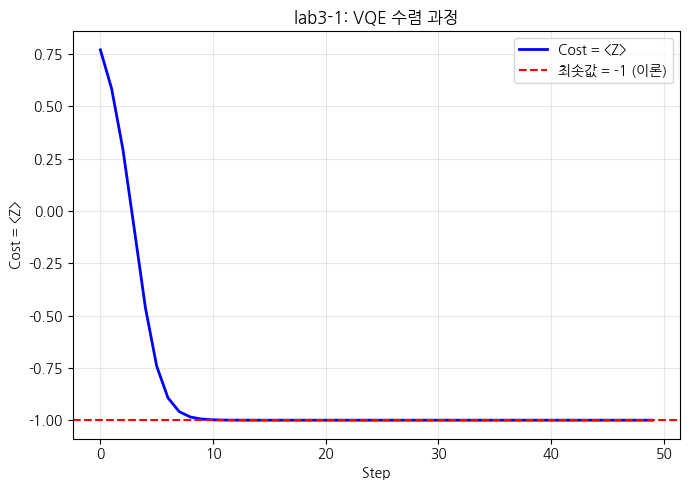

In [6]:
# 수렴 그래프
fig, ax = plt.subplots(figsize=(7,5))

ax.plot(history, 'b-', lw=2, label='Cost = <Z>')

ax.axhline(
    y=-1,
    color='r',
    ls='--',
    lw=1.5,
    label='최솟값 = -1 (이론)'
)

ax.set_xlabel("Step")
ax.set_ylabel("Cost = <Z>")
ax.set_title("lab3-1: VQE 수렴 과정")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

fig.savefig("./lab3a.png", dpi=300)

plt.show()


lab3-2: Bell 상태 & 얽힘

[회로도]


C:\Users\admin\anaconda3\envs\qml43\Lib\site-packages\pennylane\devices\device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


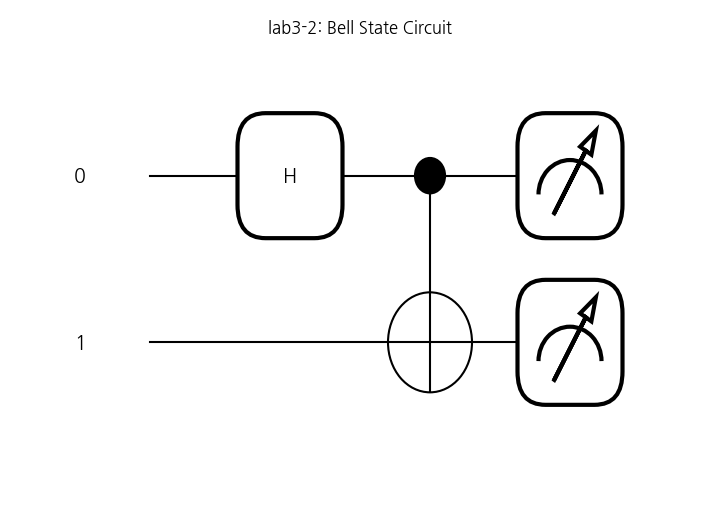

In [7]:
# ============================================================
# 3-2: Bell 상태 & 얽힘
# ============================================================

print("\n" + "=" * 60)
print("lab3-2: Bell 상태 & 얽힘")
print("=" * 60)


dev2 = qml.device(
    "default.qubit",
    wires=2,
    shots=shots
)


@qml.qnode(dev2)
def bell_probs():

    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])

    return qml.probs(wires=[0, 1])


# 회로도 출력
print("\n[회로도]")

fig, ax = qml.draw_mpl(
    bell_probs,
    decimals=3,
    style="black_white"
)()

fig.set_size_inches(7,5)

fig.suptitle("lab3-2: Bell State Circuit")

fig.savefig("./lab3b.png", dpi=300)

plt.show()

In [8]:
# ============================================================
# Bell 상태 이론 확률
# ============================================================

probs_analytic = bell_probs()

basis = ["00", "01", "10", "11"]

print("\n확률 분포")

for b, p in zip(basis, probs_analytic):

    print(f"|{b}>  P = {p:.4f}")


# ============================================================
# 상관관계 확인
# ============================================================

@qml.qnode(dev2)
def bell_corr():

    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])

    return (
        qml.expval(qml.PauliZ(0)),
        qml.expval(qml.PauliZ(1)),
        qml.expval(qml.PauliZ(0) @ qml.PauliZ(1)),
    )


z0, z1, zz = bell_corr()

print("\n상관관계")

print(f"<Z0>    = {float(z0):.4f} (이론 0)")
print(f"<Z1>    = {float(z1):.4f} (이론 0)")
print(f"<Z0Z1>  = {float(zz):.4f} (이론 1)")

corr = float(zz) - float(z0) * float(z1)

print(f"상관관계 = {corr:.4f}")


확률 분포
|00>  P = 0.5098
|01>  P = 0.0000
|10>  P = 0.0000
|11>  P = 0.4902

상관관계
<Z0>    = 0.0312 (이론 0)
<Z1>    = 0.0312 (이론 0)
<Z0Z1>  = 1.0000 (이론 1)
상관관계 = 0.9990


In [9]:
# ============================================================
# 샘플링 측정
# ============================================================

@qml.qnode(dev2)
def bell_sample():

    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])

    return qml.sample(wires=[0, 1])


raw = bell_sample()

labels_meas = [''.join(map(str, r)) for r in raw.tolist()]

count_vals = [labels_meas.count(b) for b in basis]


print(f"\n[shots={shots}] 측정 결과")

print(dict(zip(basis, count_vals)))

print("\n핵심 특징")

print("|00> 과 |11> 만 나타남")
print("→ Bell 상태의 얽힘 특징")

print("50:50이 아닌 이유 → 유한 샘플링 통계 변동")


[shots=1024] 측정 결과
{'00': 513, '01': 0, '10': 0, '11': 511}

핵심 특징
|00> 과 |11> 만 나타남
→ Bell 상태의 얽힘 특징
50:50이 아닌 이유 → 유한 샘플링 통계 변동


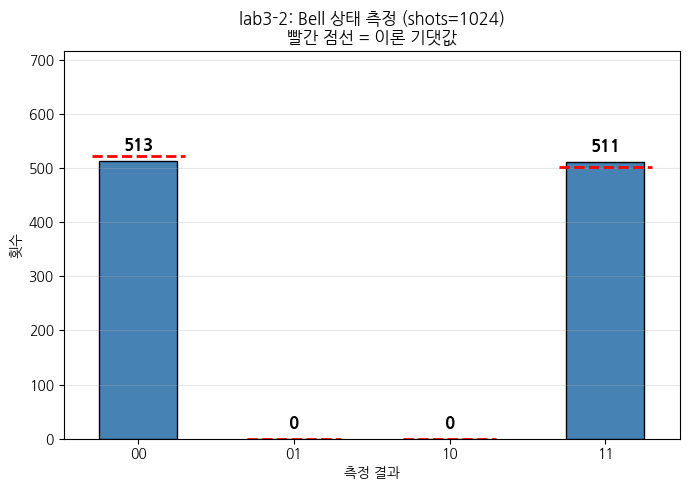

In [10]:
# ============================================================
# 시각화
# ============================================================

expected = [p * shots for p in probs_analytic]

colors = [
    'steelblue' if c > 0 else 'lightgray'
    for c in count_vals
]


fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(
    basis,
    count_vals,
    color=colors,
    edgecolor='black',
    width=0.5
)


# 이론값 표시
for i, exp in enumerate(expected):

    ax.plot(
        [i - 0.3, i + 0.3],
        [exp, exp],
        'r--',
        lw=2
    )


# 값 표시
for bar, val in zip(bars, count_vals):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        val + shots*0.02,
        str(val),
        ha='center',
        fontsize=12,
        fontweight='bold'
    )


ax.set_ylim(0, shots * 0.7)

ax.set_xlabel("측정 결과")
ax.set_ylabel("횟수")

ax.set_title(
    f"lab3-2: Bell 상태 측정 (shots={shots})\n"
    "빨간 점선 = 이론 기댓값"
)

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

fig.savefig("./lab3c.png", dpi=300)

plt.show()

In [11]:
# ============================================================
# 실습 핵심 정리
# ============================================================

print("\n핵심 개념")

print("1. VQE → 파라미터 최적화를 통해 cost 최소화")
print("2. Bell 상태 → 대표적인 얽힘 상태")
print("3. 얽힘 상태에서는 큐빗이 독립적이지 않음")
print("4. shots 측정은 통계적 변동이 존재")
print("5. shots가 커질수록 이론 확률에 수렴")


print("\nlab3 완료!")


핵심 개념
1. VQE → 파라미터 최적화를 통해 cost 최소화
2. Bell 상태 → 대표적인 얽힘 상태
3. 얽힘 상태에서는 큐빗이 독립적이지 않음
4. shots 측정은 통계적 변동이 존재
5. shots가 커질수록 이론 확률에 수렴

lab3 완료!
